In [2]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
# load in dataset with monthly t2m means across the globe from 1985-2014
t2m_means = xr.open_dataset('/home/alawyer2/era5-data/all-monthly-means.nc')

# load in original data to compare with means
years = range(1985, 2015) 
directory_path = '/projects/lortizur/cop_climate/era5/'
files_list = [directory_path+f for f in os.listdir(directory_path) if int(f[-10:-6]) in years]
ds = xr.open_mfdataset(files_list)

# convert K to ºC
ds['t2m'] = (ds['t2m'] - 273.15).assign_attrs(units='degC')

# calculate anomalies 
t2m_anoms = ds.groupby('time.month') - t2m_means
t2m_anoms 

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1985-01-01 1985-01-02 ... 2014-12-31
    realization  (time) int64 88kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    month        (time) int64 88kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12
Data variables:
    t2m          (time, lat, lon) float32 46GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>

In [ ]:
# load in AMO (Atlantic Multidecadal Oscillation) Index dataset, downloaded from https://psl.noaa.gov/data/timeseries/AMO/ 
# data are sst anomalies for Atlantic ocean. Anomalies are based on the 1951-1980 time period. 
amo_data_table = pd.read_table('/home/alawyer2/amo-data/amon.sm.data', sep=' ', skipinitialspace=True, 
                        header=None, skiprows=[0],
                        names={'year': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12},
                        skipfooter=10, # 2018-2023 are nearly all -99.99 values, so skipping these years since my data ends at 2014
                        na_values='-99.99', engine='python')

# format table into timeseries structure before converting to xarray ds. copilot helped give direction, then I modified to produce what I wanted to see
amo_long = amo_data_table.melt(id_vars='year', var_name='month', value_name='sst')
amo_long['time'] = pd.to_datetime({'year': df_melt['year'], 'month': df_melt['month'], 'day':1})
amo_ts = amo_long.set_index('time').sort_index()['sst'].to_frame()

amo_ds = amo_ts.to_xarray()
amo_ds

<xarray.Dataset> Size: 13kB
Dimensions:  (time: 840)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2017-12-01
Data variables:
    sst      (time) float64 7kB 0.101 0.101 0.101 0.105 ... 0.177 0.176 0.177

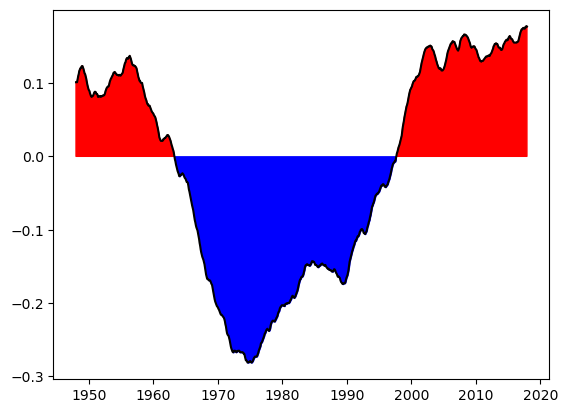

In [65]:
# define positive and negative phases of AMO, as described here: 
# https://climatedataguide.ucar.edu/climate-data/atlantic-multi-decadal-oscillation-amo
pos_amo = amo_ds['sst'].where(amo_ds['sst'] > 0)
neg_amo = amo_ds['sst'].where(amo_ds['sst'] < 0)

# plot sst values over time
plt.plot(amo_ds['time'], amo_ds['sst'], 'k')
plt.fill_between(amo_ds['time'].values, pos_amo, color='red')
plt.fill_between(amo_ds['time'].values, neg_amo, color='blue')

In [ ]:
# limit AMO data timeframe to match available t2m data 
pos_lim = pos_amo.sel(time=slice(t2m_anoms['time'][0], t2m_anoms['time'][-1]))
neg_lim = neg_amo.sel(time=slice(t2m_anoms['time'][0], t2m_anoms['time'][-1]))

# find mean of t2m values conditioned on AMO phases
pos_temps = t2m_anoms.sel(time=pos_lim.dropna(dim='time')['time']).mean(dim='time')
neg_temps = t2m_anoms.sel(time=neg_lim.dropna(dim='time')['time']).mean(dim='time')

composite_temps = {'pos_temps': pos_temps, 'neg_temps': neg_temps}
composite_temps

{'pos_temps': <xarray.Dataset> Size: 4MB
 Dimensions:  (lat: 721, lon: 1440)
 Coordinates:
   * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
 Data variables:
     t2m      (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>,
 'neg_temps': <xarray.Dataset> Size: 4MB
 Dimensions:  (lat: 721, lon: 1440)
 Coordinates:
   * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
 Data variables:
     t2m      (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>}